In [1]:
import numpy as np
import pandas as pd
from model import ProbModel
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle

In [2]:
df = pd.read_csv('../../data/processed/dataset_clean_no-outliers.csv').drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [3]:
# realignment
df['speed'] = df['speed'][6:].reset_index(drop=True)
df['power'] = df['power'][:-6].reset_index(drop=True)

normalized = (df['power'] - df['power'].min()) / (df['power'].max() - df['power'].min()) # normalize
df['power'] = np.clip(normalized, 1e-15, 1 - 1e-15)

df.dropna(inplace=True)

In [4]:
n = len(df)
train_size = int(0.7 * n)
val_size = int(0.2 * n)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size].reset_index(drop=True)
val_df = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_df = df.iloc[train_size + val_size:].reset_index(drop=True)

print(train_df.shape)
print(train_df.columns)

(30662, 5)
Index(['datetime', 'speed', 'power', 'price', 'load'], dtype='object')


In [5]:
model = ProbModel(
    binning_method='equal_width',
    interval_params=1,
    spline_k=3,
    spline_s=0.5
)

In [6]:
model.fit(train_df['speed'], train_df['power'])
train_df['pred'] = model.predict(train_df['speed'])
val_df['pred'] = model.predict(val_df['speed'])
test_df['pred'] = model.predict(test_df['speed'])

mse = mean_squared_error(train_df['power'], train_df['pred'])
print(f"Train MSE: {mse}")

mse = mean_squared_error(val_df['power'], val_df['pred'])
print(f"Validation MSE: {mse}")

mse = mean_squared_error(test_df['power'], test_df['pred'])
print(f"Test MSE: {mse}")

Train MSE: 0.031773985788937406
Validation MSE: 0.04089550901394527
Test MSE: 0.03678987265924495


In [7]:
model.get_params()

{'binning_method': 'equal_width',
 'interval_params': 1,
 'spline_k': 3,
 'spline_s': 0.5,
 'smoothing_factor': 0.01,
 'drift_factor': 0.001,
 'reset_prev_w': 0.02}

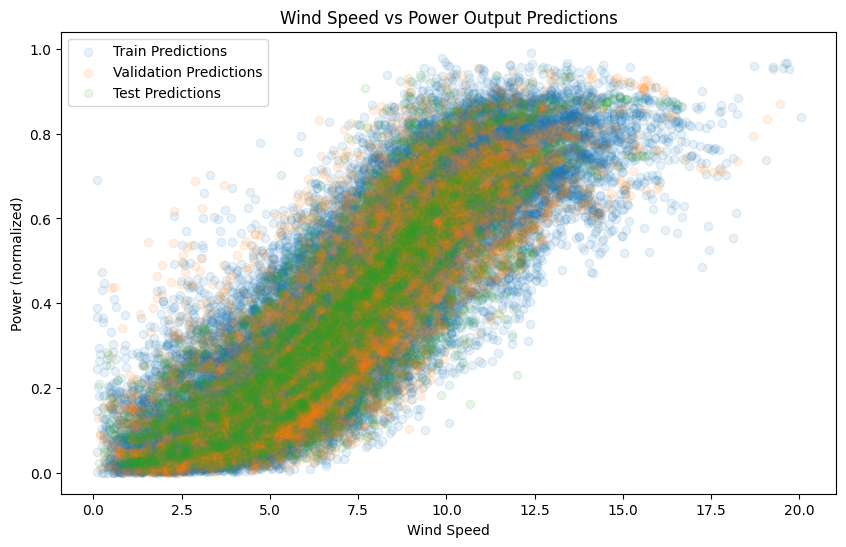

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(train_df['speed'], train_df['pred'], label='Train Predictions', alpha=0.1)
plt.scatter(val_df['speed'], val_df['pred'], label='Validation Predictions', alpha=0.1)
plt.scatter(test_df['speed'], test_df['pred'], label='Test Predictions', alpha=0.1)
plt.xlabel('Wind Speed')
plt.ylabel('Power (normalized)')
plt.title('Wind Speed vs Power Output Predictions')
plt.legend()
plt.show()

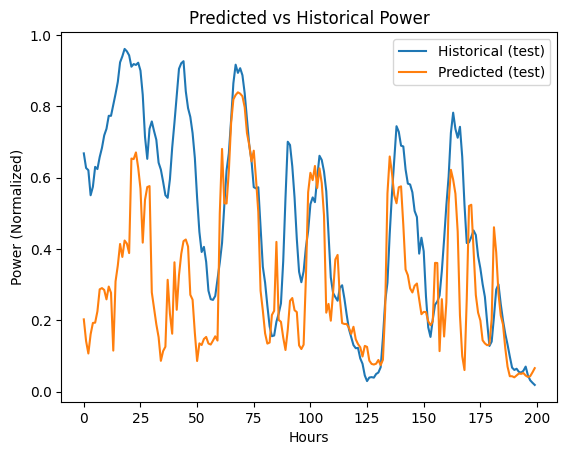

In [9]:
# plt.plot(train_df['power'][:200], label='Historical')
# plt.plot(train_df['pred'][:200], label='Predicted')

# plt.plot(val_df['power'][:200], label='Historical (val)')
# plt.plot(val_df['pred'][:200], label='Predicted (val)')

plt.plot(test_df['power'][0:200].reset_index(drop=True), label='Historical (test)')
plt.plot(test_df['pred'][0:200].reset_index(drop=True), label='Predicted (test)')

plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.title('Predicted vs Historical Power')
plt.legend()

In [10]:
a_spline = model.get_var('a_spline')
b_spline = model.get_var('b_spline')
lowers, uppers = model.get_var('intervals')

avg_speeds = []
for i in range(len(lowers)):
    lower = lowers[i]
    upper = uppers[i]
    avg_speed = (lower + upper) / 2
    avg_speeds.append(avg_speed)

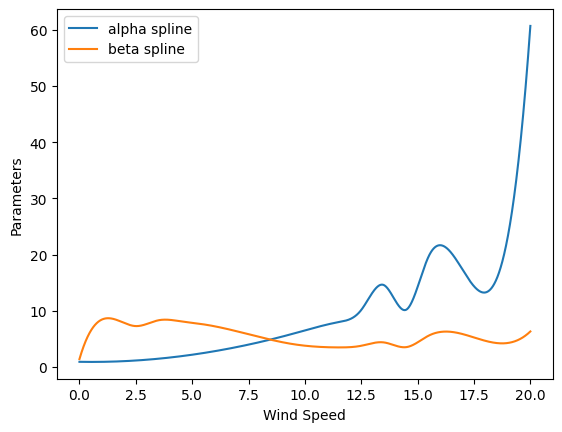

In [11]:
x = np.linspace(0, 20, 10000)
plt.plot(x, a_spline(x), label="alpha spline")
plt.plot(x, b_spline(x), label="beta spline")
plt.xlabel("Wind Speed")
plt.ylabel("Parameters")
plt.legend()

In [12]:
model.fit(train_df['speed'], train_df['power'])

# bayes

In [41]:
from skopt import BayesSearchCV

In [43]:
param_space = {
    'spline_k': [1, 2, 3, 4, 5],
    'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100, 250],
    'smoothing_factor': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2],
    'drift_factor': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05, 0.1]
}

In [45]:
opt = BayesSearchCV(
    ProbModel(
        binning_method='moving_window',
        interval_params=(1, 0.5),
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt2 = BayesSearchCV(
    ProbModel(
        binning_method='fixed',
        interval_params=[0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt3 = BayesSearchCV(
    ProbModel(
        binning_method='equal_freq',
        interval_params=100,
    ),
    param_space,
    n_iter=50,
    cv=3
)

opt4 = BayesSearchCV(
    ProbModel(
        binning_method='equal_width',
        interval_params=0.5
    ),
    param_space,
    n_iter=50,
    cv=3
)

In [47]:
print("Fitting opt1...")
opt.fit(train_df['speed'], train_df['power'])
print("Fitting opt2...")
opt2.fit(train_df['speed'], train_df['power'])
print("Fitting opt3...")
opt3.fit(train_df['speed'], train_df['power'])
print("Fitting opt4...")
opt4.fit(train_df['speed'], train_df['power'])

Fitting opt1...
Fitting opt2...
Fitting opt3...
Fitting opt4...


BayesSearchCV(cv=3, estimator=<model.ProbModel object at 0x15c795ee0>,
              search_spaces={'drift_factor': [1e-05, 0.0001, 0.001, 0.01, 0.1],
                             'reset_prev_w': [0.0001, 0.001, 0.01, 0.02, 0.05,
                                              0.1],
                             'smoothing_factor': [0.0001, 0.001, 0.01, 0.05,
                                                  0.1, 0.2],
                             'spline_k': [1, 2, 3, 4, 5],
                             'spline_s': [0, 0.01, 0.1, 0.5, 1, 2, 5, 25, 100,
                                          250]})

In [52]:
print(opt.best_params_)
print(opt2.best_params_)
print(opt3.best_params_)
print(opt4.best_params_)

OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.001, 'smoothing_factor': 0.01, 'spline_k': 4, 'spline_s': 1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 1, 'spline_s': 0.1})
OrderedDict({'drift_factor': 0.1, 'reset_prev_w': 0.0001, 'smoothing_factor': 0.001, 'spline_k': 2, 'spline_s': 0})


# Loading best_model pickle

In [4]:
with open('results/best_model.pkl', 'rb') as f:
    best = pickle.load(f)

In [24]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

In [5]:
best

{'params': {'binning_method': 'equal_width',
  'interval_params': 1,
  'spline_k': 3,
  'spline_s': 0.5,
  'smoothing_factor': 0.01,
  'drift_factor': 0.001,
  'reset_prev_w': 0.02},
 'model': <model.ProbModel at 0x11102ed20>}

In [6]:
model = best['model']

In [25]:
df['npower'] = df['npower'].clip(lower=1e-15, upper=1 - 1e-15)

In [59]:
model.fit(df['speed'], df['npower'])

In [92]:
npreds = model.predict(df['speed'])
preds = np.array(npreds) * 244.5

mse = mean_squared_error(df['npower'], npreds)
print("MSE:", mse)

mse = mean_squared_error(df['power'], preds)
print("MSE:", mse)

MSE: 0.06737942752830793
MSE: 4022.630125055198


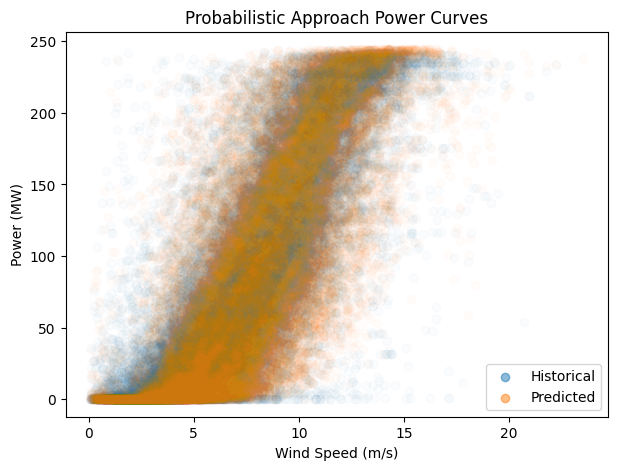

In [64]:
plt.figure(figsize=(7, 5))

plt.scatter(df['speed'], df['power'], alpha=0.02, label='Historical')
plt.scatter(df['speed'], preds, alpha=0.02, label='Predicted')

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Probabilistic Approach Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

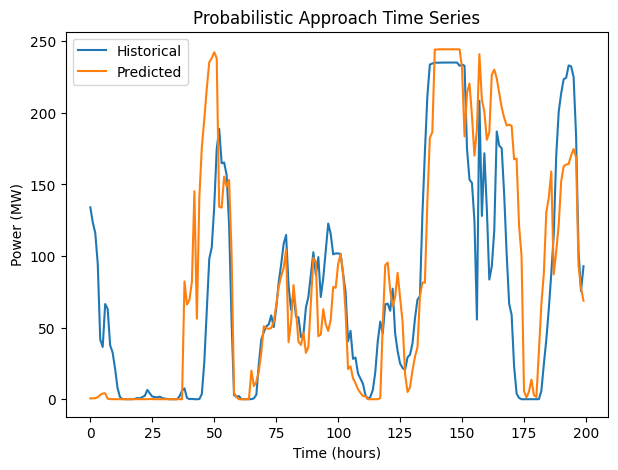

In [65]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(preds[:200], label='Predicted')
plt.title('Probabilistic Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

## save csv for we-validate

In [72]:
from datetime import datetime, timedelta

In [82]:
df['npreds'] = df['preds'] / 244.5

In [76]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [77]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    while len(time_stamps) < 34856:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

time_stamp = generate_time_stamps(datetime(2018, 1, 1, 1, 0, 0))
df['time_stamp'] = time_stamp

In [86]:
df

,time_stamp,speed,power_cf,power,npower,nspeed,preds,npreds
0,2018-01-01 01:00:00,6.384246,0.191033,134.039,0.548825,0.268745,5.739404e-01,2.347405e-03
1,2018-01-01 02:00:00,6.679563,0.220842,123.450,0.505468,0.281334,6.017519e-01,2.461153e-03
2,2018-01-01 03:00:00,6.784414,0.232067,116.143,0.475550,0.285803,6.869195e-01,2.809487e-03
3,2018-01-01 04:00:00,6.794198,0.233133,94.625,0.387444,0.286221,1.479091e+00,6.049450e-03
4,2018-01-01 05:00:00,7.114358,0.269688,41.765,0.171008,0.299868,2.924868e+00,1.196265e-02
...,...,...,...,...,...,...,...,...
34851,2021-12-23 04:00:00,2.544705,0.000000,5.338,0.021857,0.105072,2.904280e-10,1.187844e-12
34852,2021-12-23 05:00:00,2.059370,0.000000,6.463,0.026463,0.084383,2.470639e-17,1.010486e-19
34853,2021-12-23 06:00:00,3.659931,0.024277,10.312,0.042223,0.152612,6.622263e-03,2.708492e-05
34854,2021-12-23 07:00:00,4.747566,0.070125,16.813,0.068841,0.198976,7.729457e-01,3.161332e-03


In [87]:
df.to_csv('results/prob_sample_approach.csv', index=False)